1) generamos patrones donde cada posicion del vector es -1 o 1 con proba 1/2.
2) entrenamos la red.
3) hacemos actualización sincrónica, o sea actualizamos todas de un saque, solamente una iteracion!
4) Error(Pi) = cantidad de bits que difieren del patrón inicial, cuando hago esa única actualización sincrónica.
5) Error_total = sumatoria de Error(P_i) * 1/N*M. O sea el error promedio total.
6) Capacidad:  cuantos patrones le puedo enseñar a la red mientras que el error se mantenga dentro de un umbral tolerable. C(P_error) = cantidad máxima de patrones mientras que E_total < P_error / N.
Donde P_error es un umbral que fijamos nosotros.

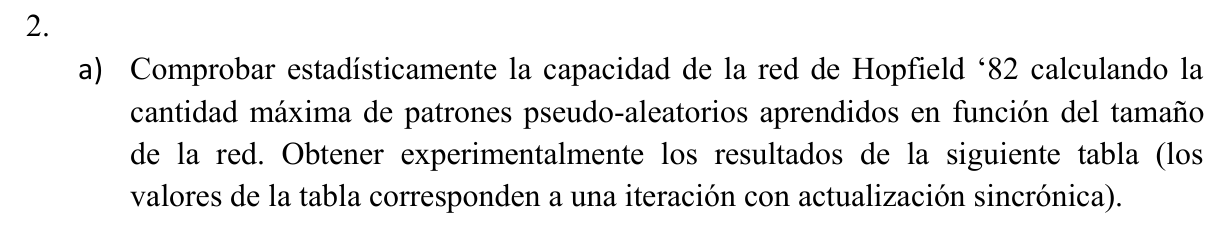

In [27]:
# Clase de la red, donde la actualización es sincrónica y es de solo una iteración.
import numpy as np

class HopfieldNetwork:
    def __init__(self, num_neurons):
        self.n = num_neurons
        self.weights = np.zeros((self.n, self.n))

    def train(self, patterns):
        for pattern in patterns:
            # Entrenamiento usando la regla de Hebb
            self.weights += np.outer(pattern, pattern)

        # Poner a cero la diagonal para evitar auto-conexiones
        np.fill_diagonal(self.weights, 0)
        return self

    def one_iteration(self, pattern_in):
      # Acualizo el pattern_in en una iteración según los valores aprendidos
      # En el train de los pesos, sincronicamente
      pattern_out = np.sign(np.dot(self.weights, pattern_in))
      return pattern_out


    def retrieve(self, pattern_in, max_epochs=100):
        # Usamos .copy() para no sobreescribir la imagen original que le pasas
        X = pattern_in.copy()
        history = [X.copy()]
        actual_epochs = 0

        for _ in range(max_epochs):
            # Guardamos una copia REAL del estado antes de empezar la época
            old_X = X.copy()

            for i in np.random.choice(np.arange(self.n), size=self.n, replace=False):
                # Producto punto (input neto de la neurona)
                net_input = np.dot(self.weights[i, :], X)

                # Asignamos 1 o -1, evitando la trampa de np.sign(0) == 0
                X[i] = 1 if net_input >= 0 else -1

            # Guardamos el estado al final de la época y sumamos 1 al contador
            history.append(X.copy())
            actual_epochs += 1

            # Si el estado no cambió en toda la época, la red convergió
            if np.array_equal(X, old_X):
                break

        # Devuelve exactamente lo que pediste
        return X, history, actual_epochs


In [28]:
# Hago una función para generar M cantidad de patrones
def generate_patterns(N, M):
  # Genero patrones donde cada posicion es -1 o 1 con igual probabilidad
  patterns = np.random.choice([-1, 1], size=(M, N))
  return patterns

In [29]:
# Hago una función para calcular el error entre dos patrones
def calculate_error(pattern1, pattern2):
  error = np.sum(pattern1 != pattern2)
  return error

In [30]:
def evaluar_set_patrones(patterns, N):
  M = len(patterns)
  network = HopfieldNetwork(N)
  network.train(patterns)

  acum_error = 0

  for pattern in patterns:
    pattern_out = network.one_iteration(pattern)
    error = calculate_error(pattern, pattern_out)
    acum_error += error

  error_total = acum_error / (M * N)
  return error_total



In [31]:
def run_ensayo(N, M_max, P_error_objetivos, pattern_bank):


  errores_por_M = []

  for M in range(1, M_max + 1):
        patterns_to_train = pattern_bank[:M]

        error_total_M = evaluar_set_patrones(patterns_to_train, N)
        errores_por_M.append(error_total_M)

  capacidades_del_ensayo = []

  for P_obj in P_error_objetivos:
        p_max = 0

        # Recorremos los errores calculados
        # El índice 0 es para M=1, el índice 1 para M=2, etc.
        for indice, error_empirico in enumerate(errores_por_M):
            M_actual = indice + 1

            # Buscamos que el error sea estrictamente menor al umbral
            if error_empirico < P_obj:
                p_max = M_actual
            else:
                # Como el error general crece, si lo superamos, dejamos de buscar
                # para este umbral específico y nos quedamos con el último p_max válido.
                break

        capacidades_del_ensayo.append(p_max/N)

  return capacidades_del_ensayo

In [32]:
def run_simulation(num_ensayos, N, M_max, P_error_objetivos, pattern_bank):
    # Lista para acumular la suma de las capacidades de todos los ensayos
    suma_capacidades = [0.0] * len(P_error_objetivos)

    print(f"Iniciando simulación: {num_ensayos} ensayos con N={N} y M_max={M_max}\n")

    for ensayo in range(num_ensayos):
        print(f"--> Ejecutando ensayo {ensayo + 1} de {num_ensayos}...")

        # Obtenemos las capacidades de una corrida
        capacidades = run_ensayo(N, M_max, P_error_objetivos, pattern_bank)

        # Sumamos los resultados al acumulador total
        for i in range(len(P_error_objetivos)):
            suma_capacidades[i] += capacidades[i]

    # --- Calcular promedios y mostrar tabla final ---
    print("\n" + "="*50)
    print("                RESULTADOS FINALES                ")
    print("="*50)
    print(f"{'P_error (Objetivo)':<20} | {'Capacidad Promedio (p_max/N)':<25}")
    print("-" * 50)

    for i, P_obj in enumerate(P_error_objetivos):
        capacidad_promedio = suma_capacidades[i] / num_ensayos
        print(f" {P_obj:<19} | {capacidad_promedio:<25.4f}")

In [33]:
N = 300
M_max = 200
P_error_objetivos = [0.001, 0.0036, 0.01, 0.05, 0.1]
n = 10

pattern_bank = generate_patterns(N, M_max)

run_simulation(n, N, M_max, P_error_objetivos, pattern_bank)

Iniciando simulación: 10 ensayos con N=300 y M_max=200

--> Ejecutando ensayo 1 de 10...
--> Ejecutando ensayo 2 de 10...
--> Ejecutando ensayo 3 de 10...
--> Ejecutando ensayo 4 de 10...
--> Ejecutando ensayo 5 de 10...
--> Ejecutando ensayo 6 de 10...
--> Ejecutando ensayo 7 de 10...
--> Ejecutando ensayo 8 de 10...
--> Ejecutando ensayo 9 de 10...
--> Ejecutando ensayo 10 de 10...

                RESULTADOS FINALES                
P_error (Objetivo)   | Capacidad Promedio (p_max/N)
--------------------------------------------------
 0.001               | 0.1167                   
 0.0036              | 0.1400                   
 0.01                | 0.1867                   
 0.05                | 0.3633                   
 0.1                 | 0.6000                   


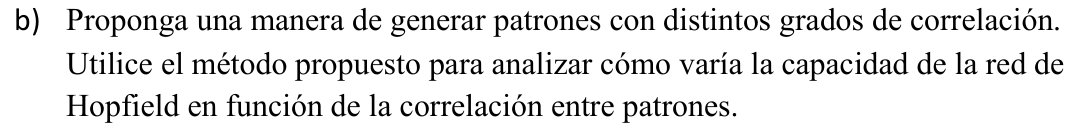

In [34]:
# Para generar patrones correlacionados en distintas medidas,
# hago una función que reciba cantidad de neuronas, cantidad
# de patrones, y un valor de correlacion. A partir de un patrón Madre,
# se flippean los valores de los pixeles con distintas probabilidades para generar los "offsprings"
def generar_patrones_correlacionados(N, M, correlacion):
  prob_mutacion = (np.sqrt(correlacion) + 1)/2
  # Corregir la llamada a generate_patterns: N es el número de neuronas, 1 es la cantidad de patrones.
  Madre = generate_patterns(N, 1)
  # Genero M copias de Madre
  Patrones = np.tile(Madre, (M,1))

  # Genero una máscara de mutación: 1 si el bit se mantiene, -1 si se flippea
  # La probabilidad de -1 (flippear) es prob_mutacion
  mascara_mutacion = np.random.choice(
        [-1, 1],
        size=(M, N),
        p=[prob_mutacion, 1 - prob_mutacion]
    )

  # Aplico la máscara de mutación a los patrones copiados de la Madre
  # Si mascara_mutacion[i,j] es -1, Patrones[i,j] se flippea.
  # Si mascara_mutacion[i,j] es 1, Patrones[i,j] se mantiene.
  Patrones_correlacionados = Patrones * mascara_mutacion

  return Patrones_correlacionados

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# Parámetros de la simulación
N = 300
M_max = 200
n_ensayos = 3 #  Promedio 3 ensayos porque sino tarda mil años en correr...
P_error_objetivos = [0.001, 0.0036, 0.01, 0.05, 0.1]
correlaciones = [0.0, 0.01, 0.03, 0.05, 0.08, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]

# Diccionario para guardar resultados {P_error: [lista_capacidades_por_corr]}
resultados_finales = {p: [] for p in P_error_objetivos}

print(f"Iniciando barrido de correlación ({n_ensayos} ensayos por punto)...")

for corr in correlaciones:
    print(f"-> Analizando correlación: {corr}")

    suma_capacidades_corr = [0.0] * len(P_error_objetivos)

    for ensayo in range(n_ensayos):
        if corr == 0:
            pattern_bank = generate_patterns(N, M_max)
        else:
            pattern_bank = generar_patrones_correlacionados(N, M_max, corr)

        capacidades = run_ensayo(N, M_max, P_error_objetivos, pattern_bank)

        for i in range(len(P_error_objetivos)):
            suma_capacidades_corr[i] += capacidades[i]

    for i, p in enumerate(P_error_objetivos):
        promedio = suma_capacidades_corr[i] / n_ensayos
        resultados_finales[p].append(promedio)



Iniciando barrido de correlación (3 ensayos por punto)...
-> Analizando correlación: 0.0
-> Analizando correlación: 0.01
-> Analizando correlación: 0.03
-> Analizando correlación: 0.05
-> Analizando correlación: 0.08
-> Analizando correlación: 0.1
-> Analizando correlación: 0.15
-> Analizando correlación: 0.2
-> Analizando correlación: 0.3
-> Analizando correlación: 0.4
-> Analizando correlación: 0.5
-> Analizando correlación: 0.6
-> Analizando correlación: 0.7
-> Analizando correlación: 0.8
-> Analizando correlación: 0.9
-> Analizando correlación: 0.95



       CAPACIDAD PROMEDIO (p_max/N) SEGÚN CORRELACIÓN
Corr (a)   | P<0.001 | P<0.0036 | P<0.01 | P<0.05 | P<0.1
-----------------------------------------------------------------
0.0        | 0.1022 | 0.1311 | 0.1789 | 0.3733 | 0.6233
0.01       | 0.1033 | 0.1367 | 0.1789 | 0.3556 | 0.5700
0.03       | 0.0689 | 0.0878 | 0.1289 | 0.2189 | 0.3200
0.05       | 0.0522 | 0.0667 | 0.0811 | 0.1378 | 0.1956
0.08       | 0.0333 | 0.0411 | 0.0489 | 0.0744 | 0.1078
0.1        | 0.0278 | 0.0333 | 0.0389 | 0.0622 | 0.0778
0.15       | 0.0211 | 0.0222 | 0.0256 | 0.0344 | 0.0489
0.2        | 0.0156 | 0.0156 | 0.0156 | 0.0211 | 0.0311
0.3        | 0.0122 | 0.0122 | 0.0122 | 0.0122 | 0.0167
0.4        | 0.0100 | 0.0100 | 0.0100 | 0.0100 | 0.0122
0.5        | 0.0078 | 0.0078 | 0.0078 | 0.0100 | 0.0133
0.6        | 0.0067 | 0.0067 | 0.0067 | 0.0067 | 0.0111
0.7        | 0.0067 | 0.0067 | 0.0067 | 0.0067 | 0.6667
0.8        | 0.0067 | 0.0067 | 0.0067 | 0.0067 | 0.6667
0.9        | 0.0067 | 0.0067 | 0.0067

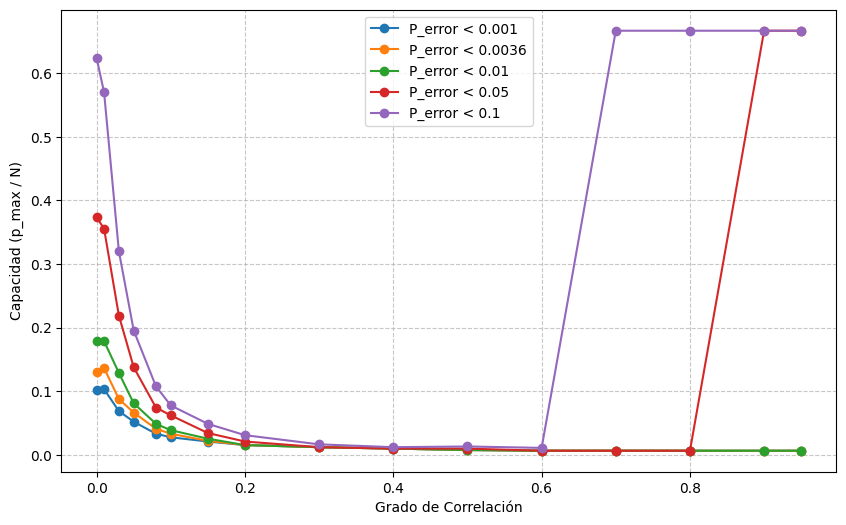

In [36]:
# --- Impresión de Tabla de Resultados ---
print("\n" + "="*65)
print("       CAPACIDAD PROMEDIO (p_max/N) SEGÚN CORRELACIÓN")
print("="*65)
header = f"{'Corr (a)':<10} | " + " | ".join([f"P<{p}" for p in P_error_objetivos])
print(header)
print("-" * 65)

for idx, corr in enumerate(correlaciones):
    row_vals = [f"{resultados_finales[p][idx]:.4f}" for p in P_error_objetivos]
    print(f"{corr:<10} | " + " | ".join(row_vals))
print("="*65 + "\n")

# --- Graficación ---
plt.figure(figsize=(10, 6))
for p in P_error_objetivos:
    plt.plot(correlaciones, resultados_finales[p], marker='o', label=f'P_error < {p}')

plt.xlabel("Grado de Correlación")
plt.ylabel("Capacidad (p_max / N)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

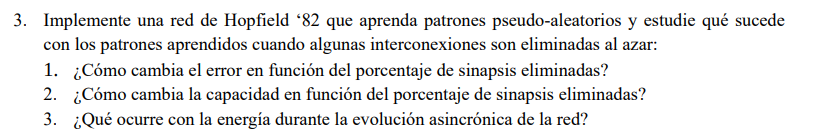

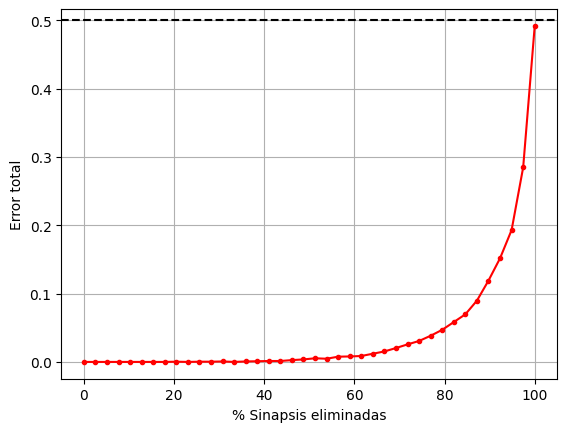

In [37]:
import numpy as np
import matplotlib.pyplot as plt

N = 200
M_1 = 15

subset_1 = generate_patterns(N, M_1)

red_1 = HopfieldNetwork(N)
red_1.train(subset_1)

def calculate_error(pattern1, pattern2):
    return np.sum(pattern1 != pattern2)

def calc_error_promedio(red, patrones):
    err_total = 0
    P = len(patrones)

    for p in patrones:
        out = red.one_iteration(p)
        out[out == 0] = 1
        err_total += calculate_error(p, out)

    return err_total / (P * red.n)


porcentajes = np.linspace(0, 1.0, 40)
errores_asimetricos = []

# me guardo una copia intacta por las dudas
W_orig = red_1.weights.copy()

# saco todos los pares de coordenadas posibles menos los de la diagonal
indices = np.where(~np.eye(N, dtype=bool))
pares = list(zip(indices[0], indices[1]))
np.random.shuffle(pares)

tot_conexiones = len(pares)
borradas = 0

for pct in porcentajes:
    target = int(pct * tot_conexiones)

    while borradas < target:
        i, j = pares[borradas]
        # borro solo en una direccion, rompiendo la simetria
        red_1.weights[i, j] = 0
        borradas += 1

    err = calc_error_promedio(red_1, subset_1)
    errores_asimetricos.append(err)

# devuelvo la red a la normalidad
red_1.weights = W_orig

plt.plot(porcentajes * 100, errores_asimetricos, 'r.-')
plt.axhline(0.5, color='black', linestyle='--')
plt.xlabel('% Sinapsis eliminadas')
plt.ylabel('Error total')
plt.grid(True)
plt.show()

Calculando asimétrico para tolerancia: 0.001...
Calculando asimétrico para tolerancia: 0.0036...
Calculando asimétrico para tolerancia: 0.01...
Calculando asimétrico para tolerancia: 0.05...
Calculando asimétrico para tolerancia: 0.1...


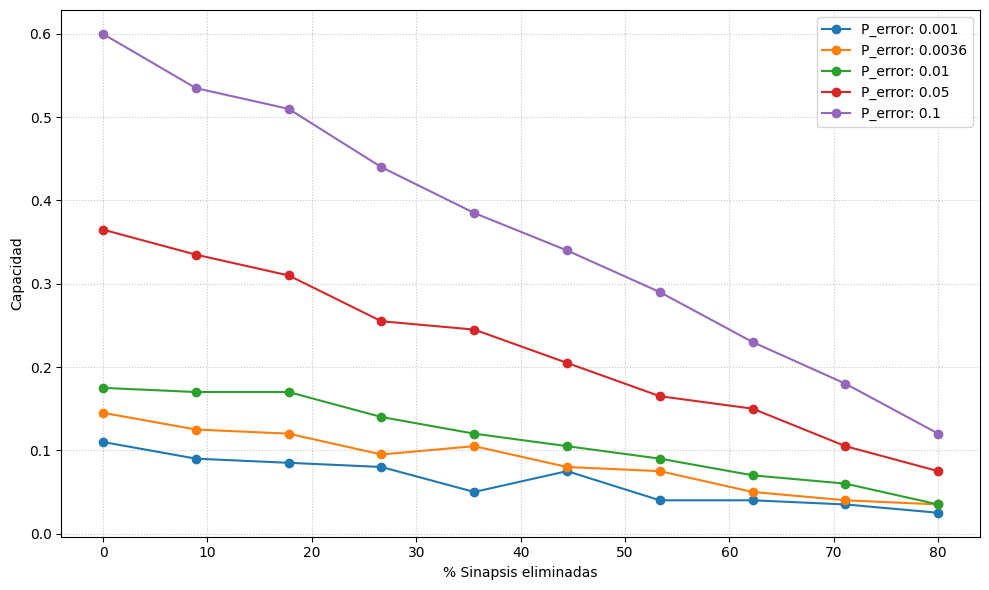

In [38]:
import numpy as np
import matplotlib.pyplot as plt

def generate_patterns(N, M):
    return np.random.choice([-1, 1], size=(M, N))

N = 200
M_max = 120
porcentajes = np.linspace(0, 0.8, 10)
P_error_objetivos = [0.001, 0.0036, 0.01, 0.05, 0.1]

resultados = {tol: [] for tol in P_error_objetivos}

indices = np.where(~np.eye(N, dtype=bool))
pares = list(zip(indices[0], indices[1]))
tot_conexiones = len(pares)

for tol in P_error_objetivos:
    print(f"Calculando asimétrico para tolerancia: {tol}...")
    capacidades = []

    for pct in porcentajes:
        target_borrar = int(pct * tot_conexiones)

        pares_mezclados = pares.copy()
        np.random.shuffle(pares_mezclados)
        a_borrar = pares_mezclados[:target_borrar]

        banco_patrones = generate_patterns(N, M_max)
        capacidad_alcanzada = M_max

        for M in range(1, M_max + 1):
            pats = banco_patrones[:M]

            red = HopfieldNetwork(N)
            red.train(pats)

            for i, j in a_borrar:
                red.weights[i, j] = 0

            err = calc_error_promedio(red, pats)

            if err > tol:
                capacidad_alcanzada = M - 1
                break

        capacidades.append(capacidad_alcanzada / N)

    resultados[tol] = capacidades

plt.figure(figsize=(10, 6))

for tol in P_error_objetivos:
    plt.plot(porcentajes * 100, resultados[tol], marker='o', label=f'P_error: {tol}')

plt.xlabel('% Sinapsis eliminadas')
plt.ylabel('Capacidad')
plt.xlabel('% Sinapsis eliminadas')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

--- Resultados de la recuperación ---
Ruido inicial: 10% -> Error final:   0.0% (0 píxeles mal)
Ruido inicial: 20% -> Error final:   0.0% (0 píxeles mal)
Ruido inicial: 30% -> Error final:   0.0% (0 píxeles mal)
Ruido inicial: 50% -> Error final:  37.5% (75 píxeles mal)


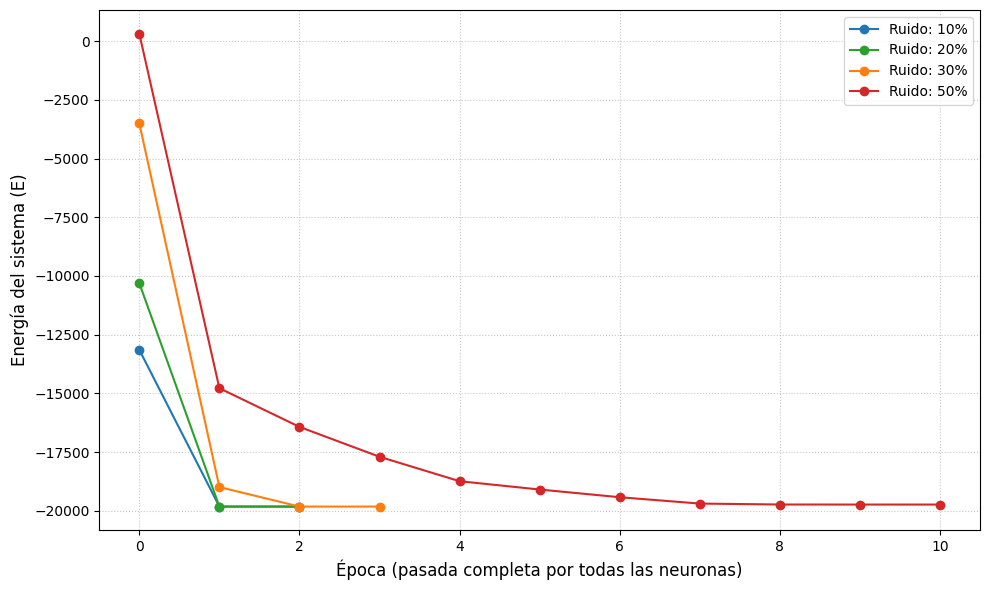

In [39]:
import numpy as np
import matplotlib.pyplot as plt

N = 200
M = 15
banco = generate_patterns(N, M)

red = HopfieldNetwork(N)
red.train(banco)

def calcular_energia(W, estado):
    return -0.5 * np.dot(estado, np.dot(W, estado))

def aplicar_ruido(patron, porcentaje_ruido):
    ruido = np.random.choice([-1, 1], size=len(patron), p=[porcentaje_ruido, 1 - porcentaje_ruido])
    return patron * ruido

patron_original = banco[0]

niveles_ruido = [0.10, 0.20, 0.30, 0.50]
colores = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']

plt.figure(figsize=(10, 6))

print("--- Resultados de la recuperación ---")

for i, pct in enumerate(niveles_ruido):
    patron_ruidoso = aplicar_ruido(patron_original, pct)

    # agarro el estado final ademas del historial
    estado_final, history, _ = red.retrieve(patron_ruidoso)

    # me fijo cuantos bits quedaron distintos respecto al original sin ruido
    bits_distintos = np.sum(estado_final != patron_original)
    error_porcentual = (bits_distintos / N) * 100

    print(f"Ruido inicial: {pct*100:2.0f}% -> Error final: {error_porcentual:5.1f}% ({bits_distintos} píxeles mal)")

    energias = [calcular_energia(red.weights, s) for s in history]
    plt.plot(energias, marker='o', linestyle='-', color=colores[i], label=f'Ruido: {pct*100:.0f}%')

plt.xlabel('Época (pasada completa por todas las neuronas)', fontsize=12)
plt.ylabel('Energía del sistema (E)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

--- Resultados de recuperación (Ruido inicial fijo: 30%) ---
Daño asimétrico: 20% -> Error final:   0.0% (0 píxeles mal) - Convergió en 3 épocas
Daño asimétrico: 40% -> Error final:   0.0% (0 píxeles mal) - Convergió en 5 épocas
Daño asimétrico: 80% -> Error final:  38.0% (76 píxeles mal) - Convergió en 18 épocas


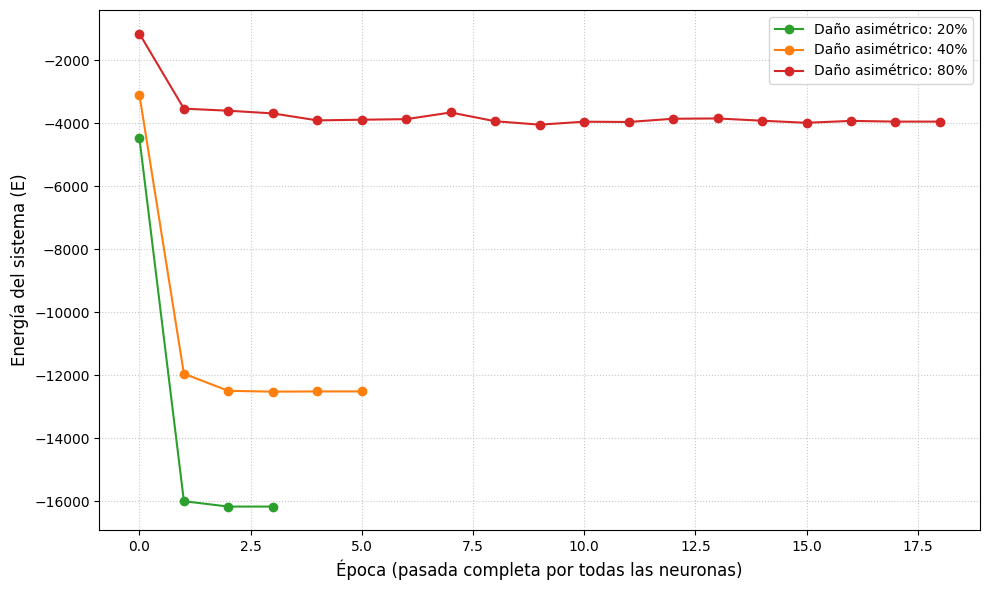

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# --- Setup inicial ---
N = 200
M = 15
banco = generate_patterns(N, M)

red = HopfieldNetwork(N)
red.train(banco)

def calcular_energia(W, estado):
    return -0.5 * np.dot(estado, np.dot(W, estado))

def aplicar_ruido(patron, porcentaje_ruido):
    ruido = np.random.choice([-1, 1], size=len(patron), p=[porcentaje_ruido, 1 - porcentaje_ruido])
    return patron * ruido

patron_original = banco[0]
ruido_inicial = 0.3
patron_ruidoso = aplicar_ruido(patron_original, ruido_inicial)

niveles_dano = [0.20, 0.40, 0.80]
colores = ['#2ca02c', '#ff7f0e', '#d62728']

plt.figure(figsize=(10, 6))

print(f"--- Resultados de recuperación (Ruido inicial fijo: {ruido_inicial*100:.0f}%) ---")

W_orig = red.weights.copy()

indices = np.where(~np.eye(N, dtype=bool))
pares_direccionales = list(zip(indices[0], indices[1]))
tot_conexiones = len(pares_direccionales)

for i, pct in enumerate(niveles_dano):
    red.weights = W_orig.copy()

    np.random.shuffle(pares_direccionales)
    target_borrar = int(pct * tot_conexiones)

    for u, v in pares_direccionales[:target_borrar]:
        red.weights[u, v] = 0

    estado_final, history, epochs = red.retrieve(patron_ruidoso)

    bits_distintos = np.sum(estado_final != patron_original)
    error_porcentual = (bits_distintos / N) * 100

    print(f"Daño asimétrico: {pct*100:2.0f}% -> Error final: {error_porcentual:5.1f}% ({bits_distintos} píxeles mal) - Convergió en {epochs} épocas")

    energias = [calcular_energia(red.weights, s) for s in history]

    plt.plot(energias, marker='o', linestyle='-', color=colores[i], label=f'Daño asimétrico: {pct*100:.0f}%')


plt.xlabel('Época (pasada completa por todas las neuronas)', fontsize=12)
plt.ylabel('Energía del sistema (E)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()